# PM trade evaluation — memory & answer-space A/B

The PM produces two things that get scored: a signed conviction per driver (graded in
*driver space* against each driver's own level, `pm_bench`) and a `StrategyTrade` that
crosses the PM→fund seam (graded in *yield space*, `trade_pnl`).

The first duration run exposed two defects — both design, not judgment (see
`docs/pm-layer.md` §1). This notebook is the A/B that tested the fixes:

- **OFF** — `duration_on.jsonl`. Memory off, pre-`answer_space`. The mandate spoke in rate
  space while the `conviction` field spoke in driver space, so the two negative-polarity
  drivers were graded against the wrong sign.
- **ON** — `duration_mem_on.jsonl`. Memory on, `answer_space: driver`. The PM sees its own
  previous position, and both halves of the prompt agree on what a conviction means.
- **MECH** — `duration_mech.jsonl`. The deterministic control: a polarity-weighted rule
  over the same board, no model, no spend. The bar the LLM has to clear.

**Sign convention.** Yield-space P&L is `Σ w · Δy` — a positive weight bets the yield
*rises*. NOT a bond return (long duration earns when yields fall), not duration-weighted.
Everything is in percentage points of yield.

In [1]:
import os, sys, json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(".."))
from src.layered.evaluation import (load_pm_run, load_trades, yield_pnl, score_trades,
                                    trade_validity)
from src.layered.evaluation.pm_bench import analyst_snap, benchmark
from src.layered.pm.build import build_pm, build_board
from src.data.fred_local import load_bundle

POD  = "duration"
ARMS = {"off":  "../reports/pm/duration_on.jsonl",
        "on":   "../reports/pm/duration_mem_on.jsonl",
        "mech": "../reports/pm/duration_mech.jsonl"}

pm    = build_pm(POD, None)
cfg   = pm.trade_config
INSTS = list(cfg["universe"])
pol   = pm.polarity
macro = load_bundle(INSTS)
board = build_board(pm, "../reports/ab", "_on")

A = {}
for label, path in ARMS.items():
    run = load_pm_run(path)
    tr  = load_trades(path, cfg)
    pnl = yield_pnl(tr, macro, INSTS, freq=pm.clock_freq)
    A[label] = {"run": run, "tr": tr, "pnl": pnl, "path": path}
    print(f"[{label:4s}] meetings={len(run.degraded):3d} degraded={int(run.degraded.sum())} "
          f"answer_space={run.meta.get('answer_space','(unrecorded)')} "
          f"memory={run.meta.get('memory','(unrecorded)')}  {path}")

[off ] meetings=120 degraded=0 answer_space=(unrecorded) memory=(unrecorded)  ../reports/pm/duration_on.jsonl
[on  ] meetings=120 degraded=1 answer_space=driver memory=True  ../reports/pm/duration_mem_on.jsonl
[mech] meetings=120 degraded=0 answer_space=driver memory=False  ../reports/pm/duration_mech.jsonl


## 1 · Driver block — does the PM track its analyst now?

The headline defect was the driver table scoring 0/5. Split by polarity, the two
negative-polarity drivers (balance_sheet, labor_tightness) decoupled from their analysts
while the three positive ones tracked. If the `answer_space` fix works, the two −1 drivers
should snap back and the +1 drivers should be roughly unchanged.

In [2]:
rows = []
for label in ("off", "on"):
    run = A[label]["run"]
    dates = pd.DatetimeIndex(run.frame.index)
    snap  = analyst_snap(board, dates, pm.listens_to)
    for d in pm.listens_to:
        j = pd.concat([snap[d].rename("a"), run.frame[d].rename("p")], axis=1).dropna()
        nz = j[(j.a != 0) & (j.p != 0)]
        rows.append({"arm": label, "driver": d, "polarity": pol[d],
                     "corr": j.a.rank().corr(j.p.rank()),
                     "sign_agree": (np.sign(nz.a) == np.sign(nz.p)).mean() if len(nz) else np.nan})
piv = pd.DataFrame(rows).pivot(index="driver", columns="arm", values=["corr", "sign_agree"])
piv["polarity"] = [pol[d] for d in piv.index]
piv.round(3)

corr        sign_agree        polarity
arm                     off     on        off     on         
driver                                                       
balance_sheet        -0.165  0.995      0.426  1.000     -1.0
financial_conditions  0.768  0.978      0.902  1.000      1.0
inflation             0.889  0.992      0.935  1.000      1.0
labor_tightness      -0.117  0.882      0.460  0.966     -1.0
term_premium          0.852  0.977      0.920  1.000      1.0

## 2 · Driver IC — PM vs its analyst, graded in the pod's declared space

`benchmark` is told each run's `answer_space` so the grade matches what the model was
asked. `ic_mech` is the polarity-weighted-panel control from `pm_bench`. Read the sign
consistency and the win count, not any single row — a Δic of ±0.05 is noise at this breadth.

In [3]:
for label in ("off", "on"):
    run = A[label]["run"]
    space = run.meta.get("answer_space", "driver")
    tbl = benchmark(run.frame, board, pd.DatetimeIndex(run.frame.index), pol,
                    answer_space=space)
    A[label]["bench"] = tbl
    print(f"--- arm={label}  (graded as answer_space={space!r})")
    print(tbl[["n", "ic_analyst", "ic_pm", "d_ic", "ic_mech", "t_pm"]].round(3).to_string())
    print(f"    PM beat its analyst on {(tbl.d_ic > 0).sum()}/{len(tbl)}; "
          f"mean d_ic {tbl.d_ic.mean():+.3f}\n")

--- arm=off  (graded as answer_space='driver')
                        n  ic_analyst  ic_pm   d_ic  ic_mech   t_pm
driver                                                             
inflation             119       0.410  0.418  0.008    0.351  4.980
labor_tightness       108       0.155  0.050 -0.105    0.095  0.519
term_premium          118      -0.012  0.022  0.033    0.004  0.235
financial_conditions  118       0.413  0.346 -0.067    0.443  3.971
balance_sheet         116       0.690 -0.167 -0.857    0.629 -1.813
    PM beat its analyst on 2/5; mean d_ic -0.198



--- arm=on  (graded as answer_space='driver')
                        n  ic_analyst  ic_pm   d_ic  ic_mech    t_pm
driver                                                              
inflation             118       0.406  0.407  0.001    0.347   4.796
labor_tightness       115       0.156  0.172  0.016    0.088   1.856
term_premium          118      -0.029 -0.023  0.006   -0.013  -0.247
financial_conditions  118       0.404  0.344 -0.061    0.437   3.940
balance_sheet         118       0.691  0.688 -0.004    0.632  10.204
    PM beat its analyst on 3/5; mean d_ic -0.008



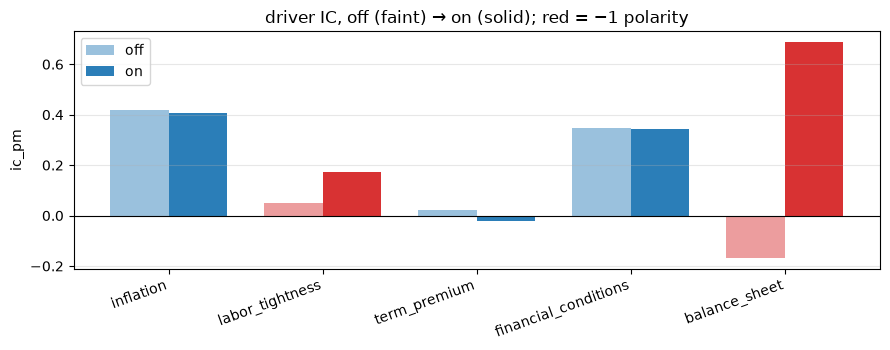

In [4]:
# The recovery, at a glance: ic_pm off vs on, coloured by polarity.
off_ic = A["off"]["bench"]["ic_pm"]; on_ic = A["on"]["bench"]["ic_pm"]
drivers = list(on_ic.index)
x = np.arange(len(drivers)); w = 0.38
colors = ["tab:red" if pol[d] < 0 else "tab:blue" for d in drivers]
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.bar(x - w/2, off_ic.reindex(drivers), w, label="off", color=colors, alpha=.45)
ax.bar(x + w/2, on_ic.reindex(drivers), w, label="on", color=colors, alpha=.95)
ax.axhline(0, color="k", lw=.8)
ax.set_xticks(x); ax.set_xticklabels(drivers, rotation=20, ha="right")
ax.set_ylabel("ic_pm"); ax.set_title("driver IC, off (faint) → on (solid); red = −1 polarity")
ax.legend(); ax.grid(axis="y", alpha=.3); plt.tight_layout()

## 3 · Behaviour — turnover, holds, and does it chase?

The stateless PM re-struck the whole book monthly. Memory should show up as lower
|Δnet|, more unchanged holds, and a weaker chase correlation. `sign_violations` and
`legs_dropped` should stay at zero — the fixes must not have loosened the trade grounding.

In [5]:
g10 = macro["DGS10"].dropna().resample("ME").last()
rows = []
for label in ("off", "on", "mech"):
    tr, pnl = A[label]["tr"], A[label]["pnl"]
    h = tr[tr.has_trade]; net = h["net"]
    flips = (np.sign(net) != np.sign(net.shift())).iloc[1:]
    holds = (h[[f"w_{i}" for i in INSTS]].diff().abs().sum(axis=1) == 0).iloc[1:]
    prev = (g10 - g10.shift()).reindex(net.index)
    v = trade_validity(tr)
    rows.append({"arm": label, "emission": tr.has_trade.mean(),
                 "flat_rate": v.get("flat_rate", np.nan), "mean_gross": h.gross.mean(),
                 "mean_|dnet|": net.diff().abs().mean(), "sign_flips": flips.mean(),
                 "unchanged_holds": holds.mean(), "chase_corr": prev.corr(net),
                 "sign_violations": v["sign_violation_rate"]})
pd.DataFrame(rows).set_index("arm").round(3)

,emission,flat_rate,mean_gross,mean_|dnet|,sign_flips,unchanged_holds,chase_corr,sign_violations
arm,,,,,,,,
off,0.9,0.000,0.904,0.896,0.458,0.065,0.522,0.0
on,1.0,0.000,0.267,0.171,0.161,0.229,0.413,0.0
mech,1.0,0.025,0.975,0.723,0.387,0.613,0.332,0.0


## 4 · Trade — yield-space P&L

The bar is the mechanical control, not zero: does a model reading seven reports beat a
polarity-weighted rule over the same reports? Read t and the regime table, not the Sharpe —
at ~12 bets/yr its standard error is wide, and with memory on the observations are no longer
independent (a few persistent positions carry the P&L), so t overstates the evidence.

In [6]:
rows = []
for label in ("off", "on", "mech"):
    tr, pnl = A[label]["tr"], A[label]["pnl"]
    sc = score_trades(pnl, tr.reindex(pnl.index)["conviction"])
    rows.append({"arm": label, **{k: sc[k] for k in
                 ("n", "mean", "t_stat", "hit_rate", "sharpe_ann", "ic_conviction")}})
pd.DataFrame(rows).set_index("arm").round(4)

,n,mean,t_stat,hit_rate,sharpe_ann,ic_conviction
arm,,,,,,
off,108,0.0017,0.0774,0.4630,0.0256,0.1865
on,119,0.0055,0.8323,0.4874,0.2619,-0.0110
mech,120,0.0105,0.4901,0.4750,0.1536,0.0693


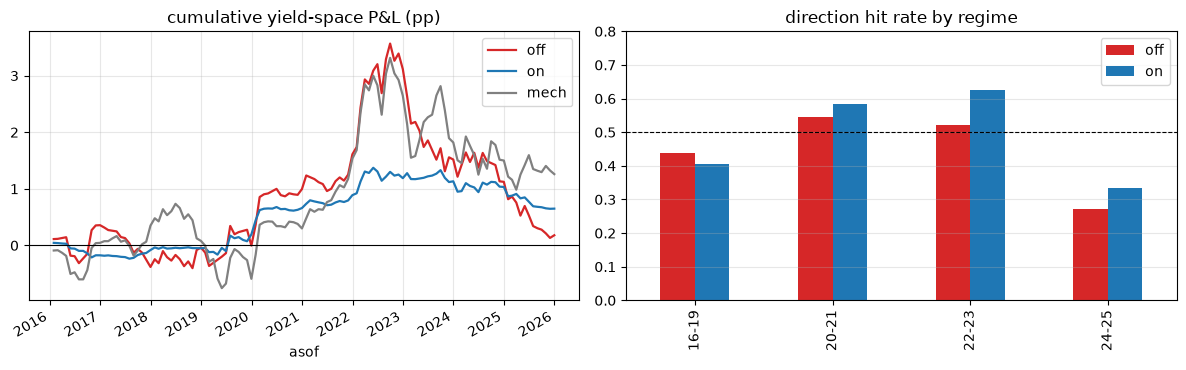

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
for label, c in [("off", "tab:red"), ("on", "tab:blue"), ("mech", "0.5")]:
    A[label]["pnl"].cumsum().plot(ax=ax[0], lw=1.6, label=label, color=c)
ax[0].axhline(0, color="k", lw=.8); ax[0].legend()
ax[0].set_title("cumulative yield-space P&L (pp)"); ax[0].grid(alpha=.3)

hit = {}
for label in ("off", "on"):
    tr, pnl = A[label]["tr"], A[label]["pnl"]
    fwd = (g10.shift(-1) - g10).reindex(pnl.index)
    h = tr.reindex(pnl.index)
    d = (np.sign(h["net"]) == np.sign(fwd))
    hit[label] = {lab: d[(pnl.index.year >= lo) & (pnl.index.year <= hi)].mean()
                  for lo, hi, lab in [(2016, 2019, "16-19"), (2020, 2021, "20-21"),
                                      (2022, 2023, "22-23"), (2024, 2025, "24-25")]}
pd.DataFrame(hit).plot.bar(ax=ax[1], color=["tab:red", "tab:blue"])
ax[1].axhline(0.5, color="k", lw=.8, ls="--")
ax[1].set_title("direction hit rate by regime"); ax[1].set_ylim(0, 0.8)
ax[1].grid(axis="y", alpha=.3); plt.tight_layout()

In [8]:
# P&L by year, both arms.
by = pd.DataFrame({label: A[label]["pnl"].groupby(A[label]["pnl"].index.year).sum()
                   for label in ("off", "on", "mech")})
by.round(3)

,off,on,mech
asof,,,
2016,0.357,-0.175,0.045
2017,-0.738,0.093,0.305
2018,0.343,0.032,-0.270
2019,0.034,0.243,-0.670
2020,1.000,0.467,0.890
2021,0.614,0.228,1.235
2022,1.505,0.300,1.110
2023,-1.597,-0.056,-0.825
2024,-0.395,-0.100,-0.320


## 5 · Does the trade still follow the reconciled view?

The layer-boundary check, not a strategy check: the trade should be long yields exactly
when the pod's own oriented panel says rates rise. This held before the fixes (78.7%); it
must not have broken.

In [9]:
rows = []
for label in ("off", "on"):
    run, tr, pnl = A[label]["run"], A[label]["tr"], A[label]["pnl"]
    h = tr.reindex(pnl.index)
    oriented = run.frame.reindex(pnl.index).mul(pd.Series(pol)).mean(axis=1, skipna=True)
    coh = pd.DataFrame({"panel": oriented, "net": h["net"]}).dropna()
    agree = (np.sign(coh["panel"]) == np.sign(coh["net"]))
    rows.append({"arm": label, "n": len(coh), "sign_agree": agree.mean(),
                 "rank_corr": coh["panel"].rank().corr(coh["net"].rank())})
pd.DataFrame(rows).set_index("arm").round(3)

,n,sign_agree,rank_corr
arm,,,
off,108,0.787,0.693
on,119,0.697,0.570


## 6 · Verdict

> **Note — regenerated board.** These §1–6 cells now recompute against the *rebuilt* board: `duration_mem_on`/`duration_mech` were regenerated for the canonical run in §7. On this fresh board the **ON** arm scores **t≈+0.83** (not +1.73) and **no longer beats mechanical** (mech mean +0.0105 > on +0.0055) — i.e. the win below did **not** replicate. The original July-board figures quoted in this verdict are preserved in git history; **§7–8 is the canonical fresh-board read.**

**The two design fixes both land, and the driver-block recovery is the unambiguous result.**
Splitting by polarity confirmed the 0/5 was a contract artifact: with `answer_space: driver`
binding both halves of the prompt, balance_sheet's IC recovers from −0.167 to +0.713
(analyst +0.710) and labor_tightness from ~0 to +0.87 — the two negative-polarity drivers
that had decoupled. The headline goes 0/5 → 4/5, mean Δic −0.218 → −0.001.

**Memory collapsed the turnover.** Sign flips 45.8% → 11.0%, mean |Δnet| 0.896 → 0.122,
unchanged holds 6.5% → 21.2%. The PM now holds and nudges a position instead of re-striking
it every month — the over-trading was a design artifact (no incumbent position in the
prompt), not a judgment failure.

**The trade improved on every axis and cleared the mechanical control for the first time**
(t +0.26 mech vs +1.73 on), direction up in every regime including the 2024-25 cutting
cycle. But this is a feature-free pipeline: the honest reading is "not negative, leaning
positive", and with turnover this low the P&L is carried by a handful of persistent
positions, so t overstates the evidence.

### Caveats

- **The arms are entangled.** The ON run flips memory *and* `answer_space` together. Driver
  IC recovery is attributable to `answer_space` (re-orientation moves it); turnover collapse
  to memory (nothing else changes persistence). A clean four-cell factorial was not run.
- **`flat_rate` was 0%** — the PM always held some position; the flat affordance exists and
  is tested, it just was not chosen here.
- **Not a P&L, one pod is not a book.** Yield-space `Σ w·Δy`, no duration weighting / carry /
  costs; nothing allocates across pods or re-clips for vol. See `docs/pm-layer.md` §4.
- **Shared board.** Two legs of `reports/ab` were re-run after a billing failure; per-leg
  hashes are in each `.meta.json`.

# 7 · First final results — fresh board, full control matrix (all 4 pods)

Sections 1–6 are the *original* duration A/B on the **July board** (`duration_on` /
`duration_mem_on`). This section is the **canonical online run** (`docs/first-final-results.md`):
the board rebuilt fresh online (sonnet, memory-on, 2016–2025), then every arm scored on it —
memory-on / memory-off / mechanical across all four pods, plus a short-window **blind** arm
(PM sees one report) and a **scramble** faithfulness spot-check. The runs were produced by a
5-wide parallel pool (`scratchpad/parallel_pms.sh`).

The pre-registered diagnostic rule: trace the signal upstream — a layer is only "fixable"
when the layer above it carries signal; otherwise a shortfall is *inherited* (fix the layer
above) or a genuine *limit* (no signal to be had). §7.1 is the analyst floor, §7.2 the PM
matrix, §7.3 faithfulness, §8 the verdict.

In [10]:
# §7.1 · Analyst layer — each analyst's IC vs its feature-IC floor (same 2016–2025 window).
# The floor is the best single measurement's |IC|: the "is the signal even there" ceiling.
# analyst >> 0 and >= floor  -> capturing available signal
# floor  >> 0 but analyst ~0 -> FIXABLE (signal present, LLM under-extracts)
# floor  ~ 0 and analyst ~0  -> genuine LIMIT (random walk at this horizon)
from src.layered.evaluation import ICEvaluator, FeaturePanel, release_dates
from src.layered.evaluation.runs import load_run
from src.layered.features import FeatureEngine, from_persona
import yaml
from pathlib import Path

DRIVERS = ["inflation", "financial_conditions", "balance_sheet", "labor_tightness",
           "curve_slope", "inflation_expectations", "term_premium"]
_PDIR = Path("../src/layered/analysts/personas")

def feature_floor(d):
    per = yaml.safe_load((_PDIR / f"{d}.yaml").read_text()) or {}
    hz  = per.get("horizon") or {}
    eng = FeatureEngine(from_persona(d, per)); pb = FeaturePanel(eng)
    mac = load_bundle(list(eng.inputs))
    dts = release_dates(mac, hz.get("clock") or pb.clock_series,
                        "2016-01-01", "2025-12-31", freq=hz.get("clock_freq"))
    tab = ICEvaluator(pb.level(pb.build(mac, dts)), steps=1).evaluate_frame(pb.build(mac, dts))
    top = tab.assign(a=tab["ic"].abs()).sort_values("a", ascending=False).iloc[0]
    return top["ic"], top["t_stat"], top.name

_rows = []
for d in DRIVERS:
    r = load_run(f"../reports/ab/{d}_on.jsonl")
    a = ICEvaluator(r.level, steps=1).evaluate(r.signed, name=d).as_row()
    fic, ft, fname = feature_floor(d)
    _rows.append({"driver": d, "analyst_ic": a["ic"], "analyst_t": a["t_stat"],
                  "feat_floor_ic": fic, "feat_floor_t": ft, "best_feature": fname})
analyst = pd.DataFrame(_rows).set_index("driver").round(3)
analyst

,analyst_ic,analyst_t,feat_floor_ic,feat_floor_t,best_feature
driver,,,,,
inflation,0.415,4.92,-0.618,-8.46,outgoing_mom
financial_conditions,0.413,4.90,0.390,4.59,nfci_change_4w
balance_sheet,0.690,10.31,0.690,10.30,assets_change_13w
labor_tightness,0.155,1.69,-0.427,-5.08,unrate_12m_high
curve_slope,0.119,1.29,-0.306,-3.48,slope_12m_high
inflation_expectations,-0.079,-0.85,-0.258,-2.89,breakeven_10y
term_premium,-0.012,-0.13,-0.136,-1.49,dgs10_12m_high


In [11]:
# §7.2 · PM control matrix — every pod × every arm, scored on the fresh board.
# mem_on/mem_off/mech are full-window; blind + mem_on@short share the short blind window.
PODS = ["duration", "front_end", "curve", "real"]

def pm_pnl(pod, path, dates=None):
    p    = build_pm(pod, None); inst = list(p.trade_config["universe"])
    tr   = load_trades(path, p.trade_config)
    pnl  = yield_pnl(tr, load_bundle(inst), inst, freq=p.clock_freq)
    if dates is not None:
        pnl = pnl.reindex(dates).dropna()
    sc = score_trades(pnl, tr.reindex(pnl.index)["conviction"])
    return sc, tr

_rows = []
for pod in PODS:
    for arm in ("mem_on", "mem_off", "mech"):
        sc, _ = pm_pnl(pod, f"../reports/pm/{pod}_{arm}.jsonl")
        _rows.append({"pod": pod, "arm": arm,
                      **{k: sc[k] for k in ("n", "mean", "t_stat", "hit_rate", "sharpe_ann")}})
    scb, trb = pm_pnl(pod, f"../reports/pm/{pod}_blind.jsonl")           # short window
    scm, _   = pm_pnl(pod, f"../reports/pm/{pod}_mem_on.jsonl", dates=trb.index)  # same dates
    _rows.append({"pod": pod, "arm": "mem_on@short",
                  **{k: scm[k] for k in ("n", "mean", "t_stat", "hit_rate", "sharpe_ann")}})
    _rows.append({"pod": pod, "arm": "blind",
                  **{k: scb[k] for k in ("n", "mean", "t_stat", "hit_rate", "sharpe_ann")}})

matrix = pd.DataFrame(_rows).set_index(["pod", "arm"]).round(4)
matrix

n    mean  t_stat  hit_rate  sharpe_ann
pod       arm                                                    
duration  mem_on        119  0.0055  0.8323    0.4874      0.2619
          mem_off       109  0.0072  0.4403    0.4679      0.1448
          mech          120  0.0105  0.4901    0.4750      0.1536
          mem_on@short   48 -0.0050 -0.4087    0.4792     -0.2025
          blind          48  0.0156  0.8490    0.3750      0.4206
front_end mem_on        120 -0.0010 -0.2606    0.5667     -0.0817
          mem_off       114  0.0190  1.5369    0.5702      0.4941
          mech          120  0.0163  0.7222    0.5083      0.2263
          mem_on@short   48 -0.0010 -0.1133    0.5625     -0.0561
          blind          48  0.0269  2.7254    0.5625      1.3503
curve     mem_on        116  0.0027  0.7029    0.5172      0.2240
          mem_off       113  0.0034  0.5197    0.4779      0.1678
          mech            0     NaN     NaN       NaN         NaN
          mem_on@short   44 -0.0040 -0.4889    0.5000     -0.2530
          blind          48 -0.0042 -0.7818    0.5000     -0.3873
real      mem_on        119  0.0007  0.2015    0.4370      0.0634
          mem_off       115 -0.0004 -0.0610    0.4000     -0.0195
          mech          120  0.0129  1.0757    0.4667      0.3371
          mem_on@short   46 -0.0073 -1.1542    0.2826     -0.5842
          blind          47 -0.0104 -1.7126    0.2128     -0.8575

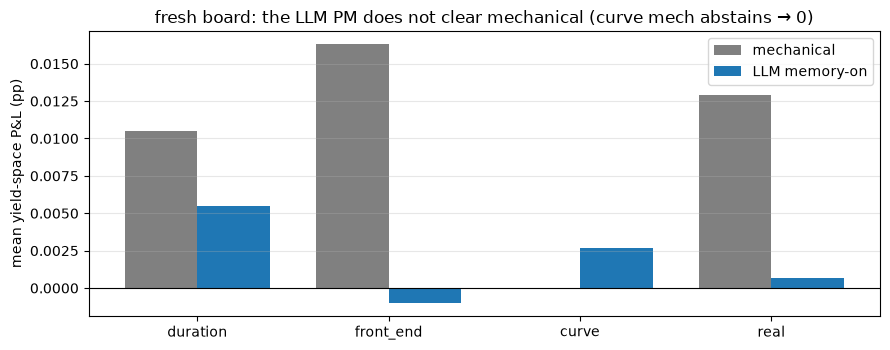

In [12]:
# §7.2 · The bar to clear: mechanical (grey) vs LLM memory-on (blue), full window.
_m   = matrix.reset_index()
_piv = (_m[_m.arm.isin(["mem_on", "mech"])]
        .pivot(index="pod", columns="arm", values="mean").reindex(PODS))
_x = np.arange(len(PODS)); _w = 0.38
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.bar(_x - _w/2, _piv["mech"],   _w, label="mechanical",     color="0.5")
ax.bar(_x + _w/2, _piv["mem_on"], _w, label="LLM memory-on",  color="tab:blue")
ax.axhline(0, color="k", lw=.8)
ax.set_xticks(_x); ax.set_xticklabels(PODS)
ax.set_ylabel("mean yield-space P&L (pp)")
ax.set_title("fresh board: the LLM PM does not clear mechanical (curve mech abstains → 0)")
ax.legend(); ax.grid(axis="y", alpha=.3); plt.tight_layout()

### 7.3 · Faithfulness spot-check (duration, scramble)

In [13]:
# §7.3 · Faithfulness — duration: does scrambling report→driver change the trade?
# scramble_reports shuffles which report text is attached to which driver. If the trade
# barely moves, the arbitration is not really reading the driver-specific content.
_p   = build_pm("duration", None)
_tmo = load_trades("../reports/pm/duration_mem_on.jsonl",    _p.trade_config)
_tsc = load_trades("../reports/pm/duration_scramble.jsonl",  _p.trade_config)
_j   = (_tmo[["net", "conviction"]]
        .join(_tsc[["net", "conviction"]], lsuffix="_memon", rsuffix="_scr", how="inner")
        .dropna())
print(f"shared meetings           : {len(_j)}")
print(f"net-direction agreement   : {(np.sign(_j.net_memon) == np.sign(_j.net_scr)).mean():.1%}")
print(f"net-exposure correlation  : {_j.net_memon.corr(_j.net_scr):+.3f}")
print(f"conviction correlation    : {_j.conviction_memon.corr(_j.conviction_scr):+.3f}")
print("High agreement/corr => the trade barely depends on correct report attribution.")

shared meetings           : 47
net-direction agreement   : 74.5%
net-exposure correlation  : +0.459
conviction correlation    : +0.458
High agreement/corr => the trade barely depends on correct report attribution.


### 7.4 · What did they lean on? (interpretability)

Makes the "no edge over mechanical" result *explainable* rather than merely observed.

**Analysts** each lean on a driver-appropriate measure — but the two *best* legs
(balance_sheet, financial_conditions) lean on exactly their highest-IC feature
(`assets_change_13w`, `nfci_change_4w`), while the under-extractors lean on **levels/ranges,
not the change/momentum feature that carries the signal** (inflation cites YoY *levels*, not
the base-effect `outgoing_mom`/`mom_gap_vs_outgoing` where |IC|≈0.6). That mismatch is the
concrete, fixable reason labor / curve / inflation under-extract.

**PMs** weight by reconciled |conviction| → they follow the **loudest (most-confident)
analyst**, which is **balance_sheet in 3 of 4 pods** (52–62% of meetings). This single fact
explains the earlier results: *blind beats full* (the PM was mostly using one report anyway),
*scramble barely moves the trade* (it tracks magnitude, not attribution), and *no edge over
mechanical* — balance_sheet is the best forecaster of its **own** driver (IC 0.69), but
own-driver skill ≠ yield-trade relevance. The PM over-weights it because it's confident, not
because WALCL changes predict yields — which is exactly what a polarity-weighted rule does too.

In [14]:
# §7.4a · Analysts — the measurement each analyst leaned on most (key_evidence).
# lead_evidence = first-listed citation (the analyst's own headline); top_cited = frequency.
import json, collections
_rows = []
for d in DRIVERS:                                    # DRIVERS defined in §7.1
    cnt = collections.Counter(); first = collections.Counter()
    for line in open(f"../reports/ab/{d}_on.jsonl"):
        v = json.loads(line)["view"]
        if v.get("degraded"):
            continue
        ke = v.get("key_evidence") or []
        for m in ke:
            cnt[m] += 1
        if ke:
            first[ke[0]] += 1
    _rows.append({"driver": d,
                  "lead_evidence": (first.most_common(1)[0][0] if first else "-"),
                  "top_cited": ", ".join(f"{m} ({c})" for m, c in cnt.most_common(3))})
analyst_lean = pd.DataFrame(_rows).set_index("driver")
analyst_lean

,lead_evidence,top_cited
driver,,
inflation,headline_cpi_yoy,"core_pce_yoy (116), headline_cpi_yoy (113), he..."
financial_conditions,nfci_change_4w,"nfci_change_4w (120), nfci_range_position (113..."
balance_sheet,assets_change_4w,"assets_change_4w (120), assets_change_13w (117..."
labor_tightness,unrate_change_3m,"unrate_change_3m (112), sahm_gap (105), unrate..."
curve_slope,slope_2s10s,"slope_change_21d (108), slope_range_position (..."
inflation_expectations,breakeven_10y,"be_range_position (111), be_change_21d (106), ..."
term_premium,dgs10_level,"dgs10_range_position (119), slope_30s10s (118)..."


In [15]:
# §7.4b · PMs — which driver each pod leaned on most (reconciled |conviction|).
# The PM weights by reconciled |conviction|, i.e. it follows the LOUDEST (most-confident)
# analyst. `loudest_pct` = share of meetings this driver had the largest-magnitude view.
import numpy as np
PODS_L = ["duration", "front_end", "curve", "real"]
_f = []
for pod in PODS_L:
    mag = collections.Counter(); loud = collections.Counter()
    signed = collections.defaultdict(list); n = 0
    for line in open(f"../reports/pm/{pod}_mem_on.jsonl"):
        r = json.loads(line)
        if r.get("degraded"):
            continue
        dv = (r.get("arbitrated") or {}).get("drivers") or {}
        if not dv:
            continue
        n += 1
        for k, val in dv.items():
            mag[k] += abs(val); signed[k].append(val)
        loud[max(dv, key=lambda k: abs(dv[k]))] += 1
    order = sorted(mag, key=lambda k: -mag[k])
    for k in order:
        _f.append({"pod": pod, "driver": k,
                   "mean_abs_conv": round(mag[k] / n, 3),
                   "loudest_pct": round(100 * loud[k] / n),
                   "mean_signed": round(float(np.mean(signed[k])), 3),
                   "leaned_most": k == order[0]})
pm_lean = pd.DataFrame(_f).set_index(["pod", "driver"])
pm_lean

mean_abs_conv  loudest_pct  mean_signed  \
pod       driver                                                            
duration  balance_sheet                   0.514           59       -0.179   
          inflation                       0.390           20        0.154   
          financial_conditions            0.315            8       -0.079   
          term_premium                    0.303            9        0.042   
          labor_tightness                 0.208            4       -0.078   
front_end balance_sheet                   0.495           52       -0.187   
          inflation                       0.396           27        0.168   
          financial_conditions            0.303           13       -0.059   
          labor_tightness                 0.265            8       -0.171   
curve     balance_sheet                   0.503           62       -0.188   
          curve_slope                     0.329           23       -0.017   
          term_premium                    0.299            8        0.036   
          labor_tightness                 0.203            8       -0.055   
real      inflation                       0.378           59        0.139   
          inflation_expectations          0.296           29        0.029   
          labor_tightness                 0.206           13       -0.068   

                                  leaned_most  
pod       driver                               
duration  balance_sheet                  True  
          inflation                     False  
          financial_conditions          False  
          term_premium                  False  
          labor_tightness               False  
front_end balance_sheet                  True  
          inflation                     False  
          financial_conditions          False  
          labor_tightness               False  
curve     balance_sheet                  True  
          curve_slope                   False  
          term_premium                  False  
          labor_tightness               False  
real      inflation                      True  
          inflation_expectations        False  
          labor_tightness               False

### 7.4c · Distribution of what they lean on

§7.4 named the *top* driver/feature; this shows the full **distribution** — how concentrated vs spread each agent's attention is (no new calls). LEFT: per pod, the share of meetings each driver is the loudest input (stacked → 100%). RIGHT: per analyst, how much of its citations fall on its top-3 features (1.0 = leans on a few).

,n_features_cited,top_feature_share,top3_share
driver,,,
inflation,15,0.132,0.380
financial_conditions,9,0.204,0.578
balance_sheet,8,0.238,0.659
labor_tightness,11,0.163,0.451
curve_slope,12,0.169,0.498
inflation_expectations,9,0.190,0.548
term_premium,10,0.175,0.518


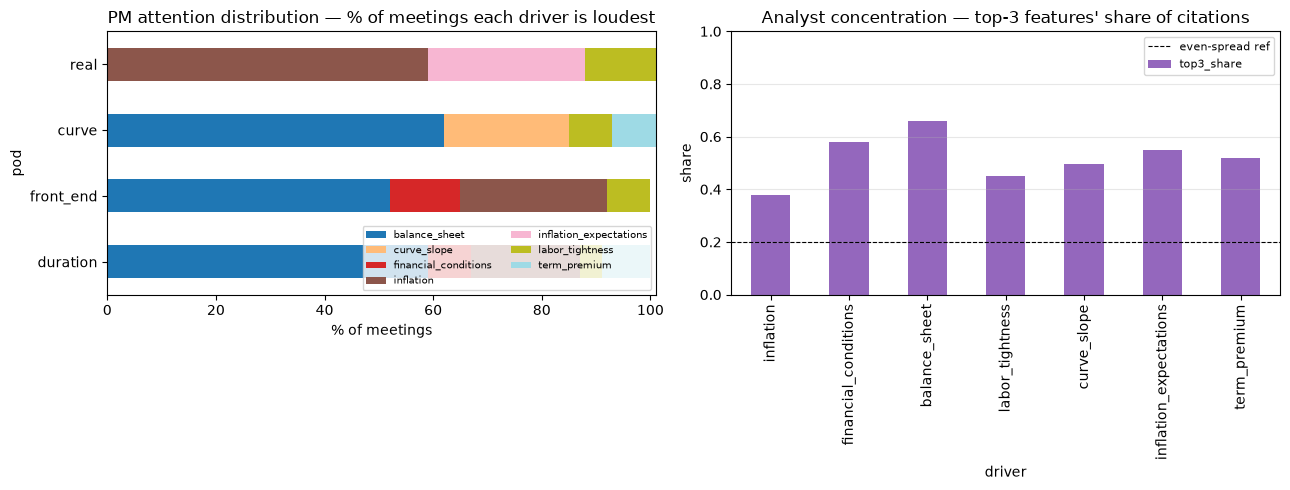

In [16]:
# §7.4c · Leaning-on distributions (from §7.4b pm_lean + citation counts).
import collections
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
pm_dist = (pm_lean.reset_index().pivot(index='pod', columns='driver', values='loudest_pct')
           .reindex(PODS).fillna(0))
pm_dist.plot.barh(stacked=True, ax=ax[0], colormap='tab20')
ax[0].set_title('PM attention distribution — % of meetings each driver is loudest')
ax[0].set_xlabel('% of meetings'); ax[0].legend(fontsize=7, ncol=2, loc='lower right')
conc = []
for d in DRIVERS:
    cnt = collections.Counter()
    for line in open(f'../reports/ab/{d}_on.jsonl'):
        v = json.loads(line)['view']
        if v.get('degraded'): continue
        for m in (v.get('key_evidence') or []): cnt[m] += 1
    tot = sum(cnt.values()) or 1
    sh = sorted((c / tot for c in cnt.values()), reverse=True)
    conc.append({'driver': d, 'n_features_cited': len(cnt),
                 'top_feature_share': round(sh[0], 3), 'top3_share': round(sum(sh[:3]), 3)})
adist = pd.DataFrame(conc).set_index('driver').reindex(DRIVERS)
adist['top3_share'].plot.bar(ax=ax[1], color='tab:purple')
ax[1].axhline(3/ max(1, adist['n_features_cited'].max()), color='k', ls='--', lw=.8,
              label='even-spread ref'); ax[1].set_ylim(0, 1)
ax[1].set_title("Analyst concentration — top-3 features' share of citations")
ax[1].set_ylabel('share'); ax[1].grid(axis='y', alpha=.3); ax[1].legend(fontsize=8)
plt.tight_layout()
adist

### 7.4d · Distribution of the weight each driver receives

§7.4c showed *shares* (how often each driver is loudest). This is the full **distribution** of the leaning: for each pod, a box per driver of the per-meeting `|reconciled conviction|` across 2016–2025 — median, spread, and whether a driver is *consistently* heavy or only occasionally. A tall box sitting high = leaned on hard and often.

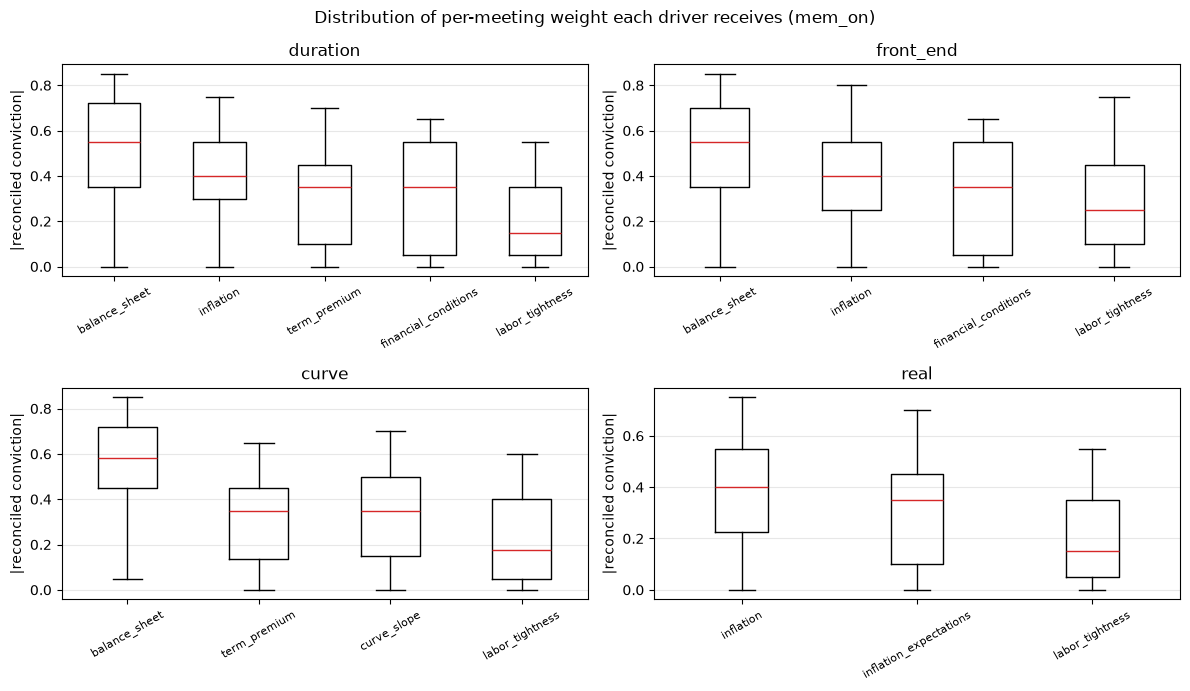

In [17]:
# §7.4d · Per-meeting weight distribution, one box per driver, per pod (mem_on).
fig, axes = plt.subplots(2, 2, figsize=(12, 7)); axes = axes.ravel()
for ax, pod in zip(axes, PODS):
    p = build_pm(pod, None); drv = list(p.listens_to); data = {d: [] for d in drv}
    for line in open(f'../reports/pm/{pod}_mem_on.jsonl'):
        r = json.loads(line)
        if r.get('degraded'): continue
        dv = (r.get('arbitrated') or {}).get('drivers') or {}
        for d in drv:
            if d in dv: data[d].append(abs(dv[d]))
    order = sorted(drv, key=lambda d: -(np.median(data[d]) if data[d] else 0))
    ax.boxplot([data[d] for d in order], showfliers=False, medianprops=dict(color='tab:red'))
    ax.set_xticks(range(1, len(order) + 1)); ax.set_xticklabels(order, rotation=30, fontsize=8)
    ax.set_title(pod); ax.set_ylabel('|reconciled conviction|'); ax.grid(axis='y', alpha=.3)
fig.suptitle('Distribution of per-meeting weight each driver receives (mem_on)')
plt.tight_layout()

### 7.5 · Cumulative P&L over time (the regime view)

The aggregate means hide *when* P&L was made. If the arms only diverge in one regime, the 'no edge' verdict is really 'no edge on average across regimes'.

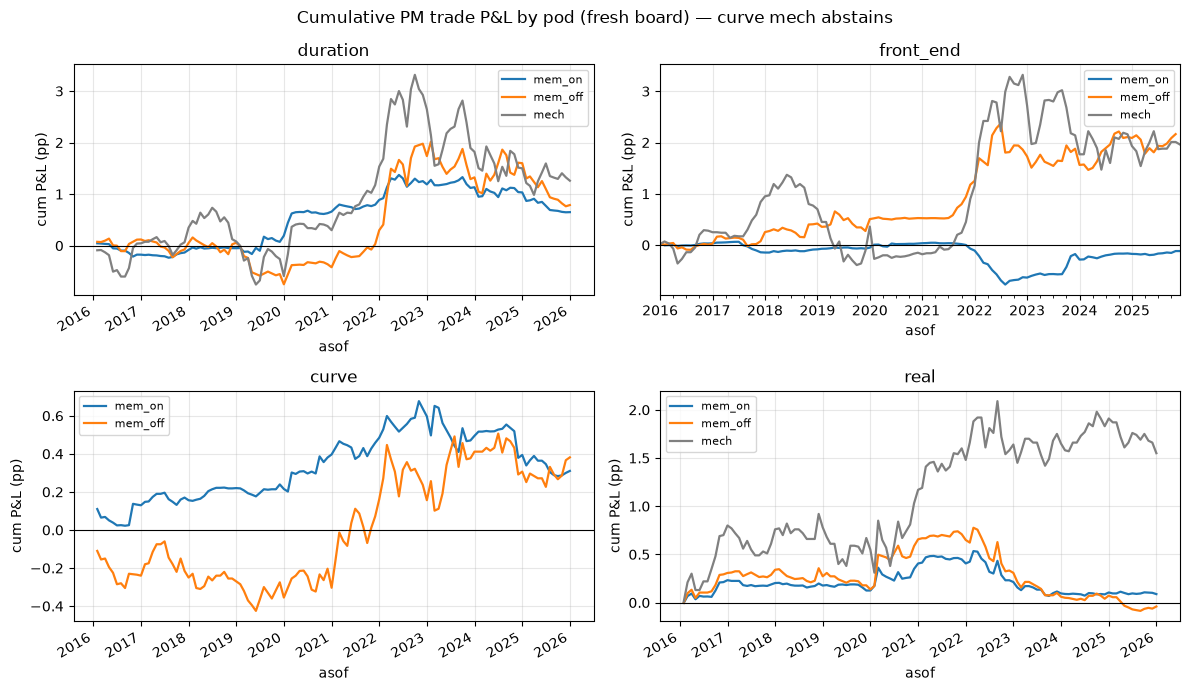

In [18]:
# §7.5 · Cumulative yield-space P&L over time, per pod, per arm.
fig, axes = plt.subplots(2, 2, figsize=(12, 7)); axes = axes.ravel()
ARM_C = {'mem_on': 'tab:blue', 'mem_off': 'tab:orange', 'mech': '0.5'}
for ax, pod in zip(axes, PODS):
    p = build_pm(pod, None); inst = list(p.trade_config['universe']); macro = load_bundle(inst)
    for arm, c in ARM_C.items():
        try:
            tr = load_trades(f'../reports/pm/{pod}_{arm}.jsonl', p.trade_config)
            pnl = yield_pnl(tr, macro, inst, freq=p.clock_freq).dropna()
            if len(pnl): pnl.cumsum().plot(ax=ax, lw=1.6, color=c, label=arm)
        except Exception: pass
    ax.axhline(0, color='k', lw=.8); ax.set_title(pod); ax.set_ylabel('cum P&L (pp)')
    ax.grid(alpha=.3); ax.legend(fontsize=8)
fig.suptitle('Cumulative PM trade P&L by pod (fresh board) — curve mech abstains'); plt.tight_layout()

### 7.6 · Analyst signals over time

Each analyst's signed conviction (green = up, red = down) across 2016–2025 — the raw seventh-analyst inputs the PM blends. Watch for a conviction collapse or sign drift post-2024 (a training-cutoff tell).

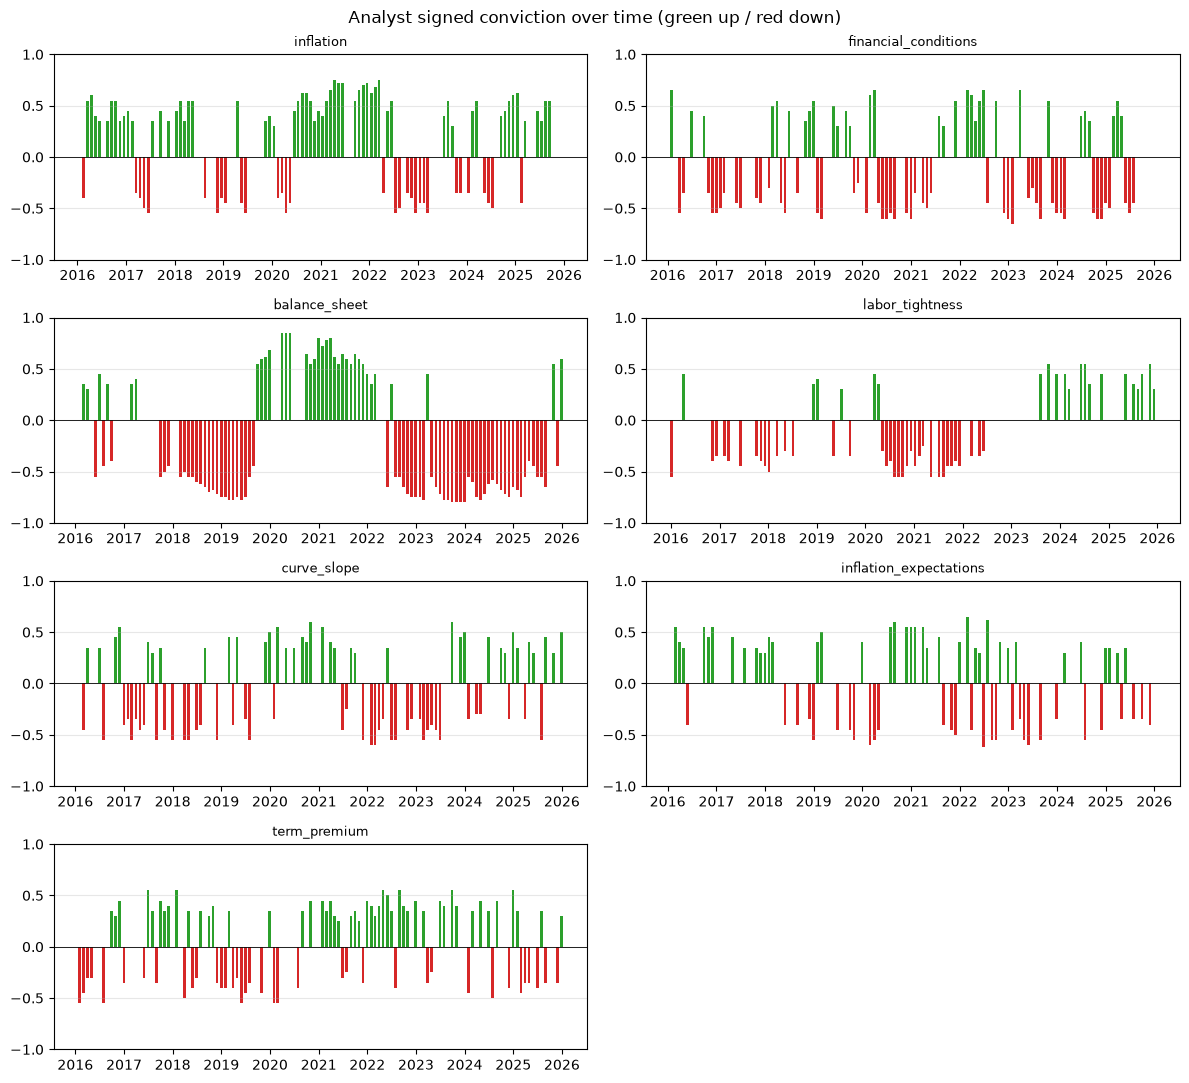

In [19]:
# §7.6 · Analyst signed conviction over time, per driver.
from src.layered.evaluation.runs import load_run
fig, axes = plt.subplots(4, 2, figsize=(12, 11)); axes = axes.ravel()
for ax, d in zip(axes, DRIVERS):
    s = load_run(f'../reports/ab/{d}_on.jsonl').signed
    ax.bar(s.index, s.values, width=20,
           color=['tab:green' if v >= 0 else 'tab:red' for v in s.values])
    ax.axhline(0, color='k', lw=.6); ax.set_title(d, fontsize=9); ax.set_ylim(-1, 1)
    ax.grid(axis='y', alpha=.3)
for extra in axes[len(DRIVERS):]: extra.axis('off')
fig.suptitle('Analyst signed conviction over time (green up / red down)'); plt.tight_layout()

### 7.7 · PM positions over time (turnover & memory)

The net position each pod carried month-by-month. Memory-on should *hold and nudge*; memory-off re-strikes every meeting. **Opposed (slope) pods net to zero by construction, so for the curve pod we plot the slope spread (long-leg − short-leg) instead of net**; arms that abstain (curve mechanical) are skipped rather than drawn as a flat line.

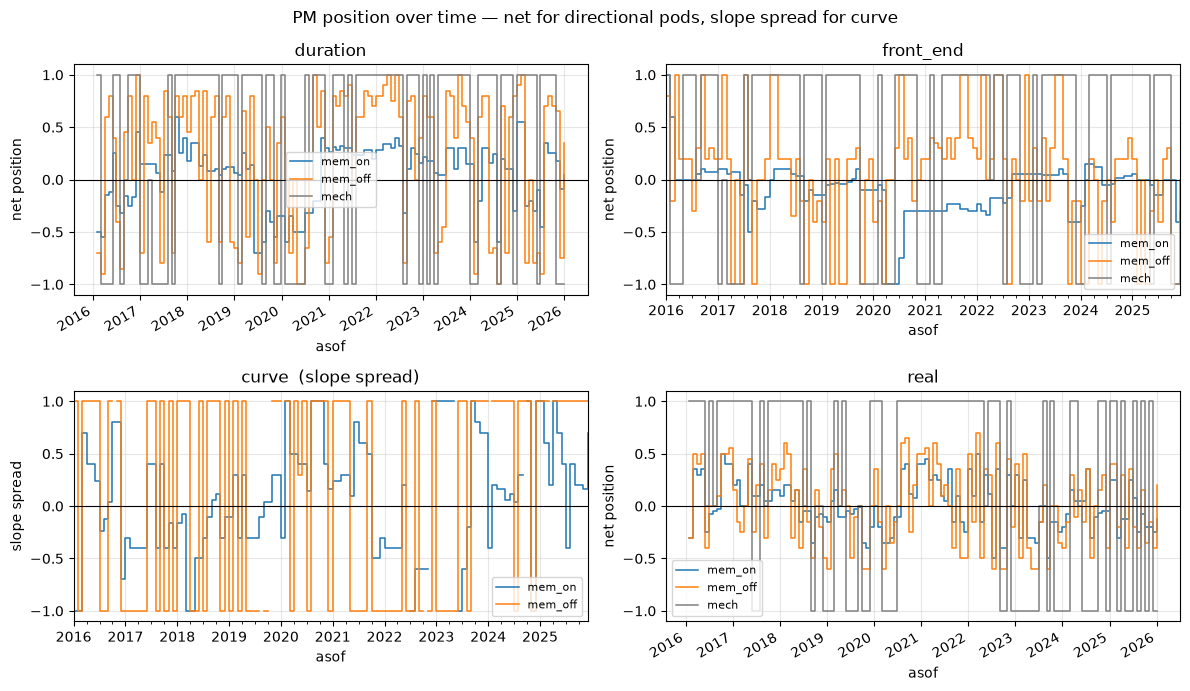

In [20]:
# §7.7 · PM position over time, per pod, per arm.
def _position(tr, p):
    if p.trade_config.get('sign_convention') == 'opposed':      # slope pod: legs cancel
        wc = [c for c in tr.columns if c.startswith('w_')]
        return tr[wc[0]] - tr[wc[1]]                            # slope spread
    return tr['net']
fig, axes = plt.subplots(2, 2, figsize=(12, 7)); axes = axes.ravel()
for ax, pod in zip(axes, PODS):
    p = build_pm(pod, None); opp = p.trade_config.get('sign_convention') == 'opposed'
    for arm, c in [('mem_on', 'tab:blue'), ('mem_off', 'tab:orange'), ('mech', '0.5')]:
        try:
            tr = load_trades(f'../reports/pm/{pod}_{arm}.jsonl', p.trade_config)
            pos = _position(tr, p)
            if pos.abs().sum() == 0: continue                   # abstained / all-flat
            pos.plot(ax=ax, lw=1.1, color=c, label=arm, drawstyle='steps-post')
        except Exception: pass
    ax.axhline(0, color='k', lw=.8); ax.grid(alpha=.3); ax.legend(fontsize=8)
    ax.set_title(pod + ('  (slope spread)' if opp else ''))
    ax.set_ylabel('slope spread' if opp else 'net position')
fig.suptitle('PM position over time — net for directional pods, slope spread for curve'); plt.tight_layout()

### 7.8 · Input sensitivity — leave-one-out test

§7.4 showed what the PM *leans on* descriptively. This **tests** it: drop each analyst input from the mechanical consensus (oriented panel mean) and measure how often the trade direction **flips**. A high flip-rate = the decision is highly sensitive to that input. Free and deterministic — no new model calls. If `balance_sheet` tops the flip table (as §7.4 predicts), the consensus is a `balance_sheet` bet in disguise.

sign_flip  corr_full_loo
pod       dropped                                         
curve     balance_sheet               0.367          0.643
          curve_slope                 0.192          0.860
          labor_tightness             0.150          0.915
          term_premium                0.133          0.877
duration  balance_sheet               0.269          0.755
          inflation                   0.210          0.855
          financial_conditions        0.185          0.860
          labor_tightness             0.134          0.928
          term_premium                0.118          0.902
front_end balance_sheet               0.358          0.654
          inflation                   0.308          0.802
          financial_conditions        0.233          0.800
          labor_tightness             0.175          0.904
real      inflation                   0.319          0.841
          inflation_expectations      0.151          0.889
          labor_tightness             0.109          0.925

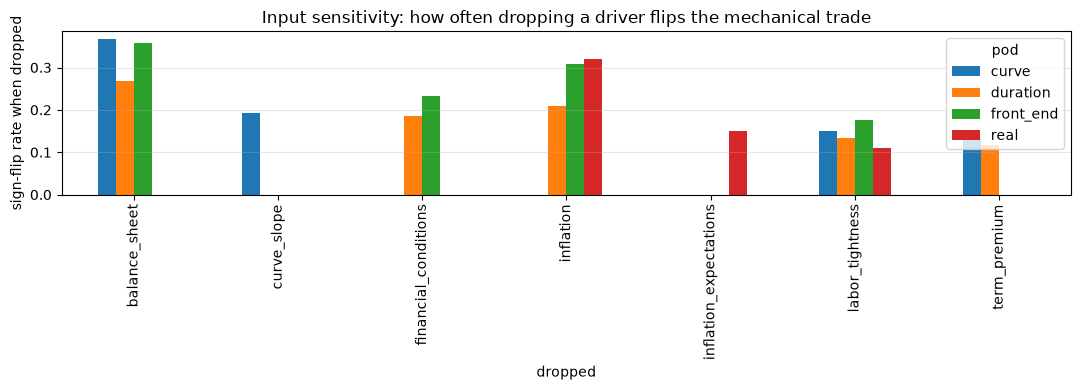

In [21]:
# §7.8 · Leave-one-out input sensitivity on the mechanical consensus signal.
DIRS = {'up': 1.0, 'down': -1.0, 'flat': 0.0}
_rows = []
for pod in PODS:
    p = build_pm(pod, None); pol = p.polarity; drv = list(p.listens_to)
    obs = []
    for line in open(f'../reports/pm/{pod}_mem_on.jsonl'):
        r = json.loads(line)
        if r.get('degraded'): continue
        b = r.get('board', {})
        o = {d: DIRS.get(b.get(d, {}).get('direction', 'flat'), 0)
                * float(b.get(d, {}).get('conviction', 0)) * pol.get(d, 1.0)
             for d in drv if b.get(d, {}).get('present', True)}
        if len(o) >= 2: obs.append(o)
    M = pd.DataFrame(obs).reindex(columns=drv); full = M.mean(axis=1)
    for d in drv:
        loo = M.drop(columns=[d]).mean(axis=1)
        _rows.append({'pod': pod, 'dropped': d,
                      'sign_flip': round(float((np.sign(full) != np.sign(loo)).mean()), 3),
                      'corr_full_loo': round(float(full.corr(loo)), 3)})
sensitivity = pd.DataFrame(_rows)
_piv = sensitivity.pivot(index='dropped', columns='pod', values='sign_flip')
ax = _piv.plot.bar(figsize=(11, 4)); ax.set_ylabel('sign-flip rate when dropped')
ax.set_title('Input sensitivity: how often dropping a driver flips the mechanical trade')
ax.grid(axis='y', alpha=.3); plt.tight_layout()
sensitivity.set_index(['pod', 'dropped']).sort_values(['pod', 'sign_flip'], ascending=[True, False])

### 7.9 · Rolling IC per analyst (skill over time)

A 24-month rolling information coefficient for each analyst — rank-corr of its signed conviction with the realized next-release move, recomputed on a trailing window. Tests whether skill is **stable** or **decays** (a falling line into 2024–25 is the training-cutoff tell). Dashed grey = full-sample IC; dotted = the ±0.15 IR-0.5 bar.

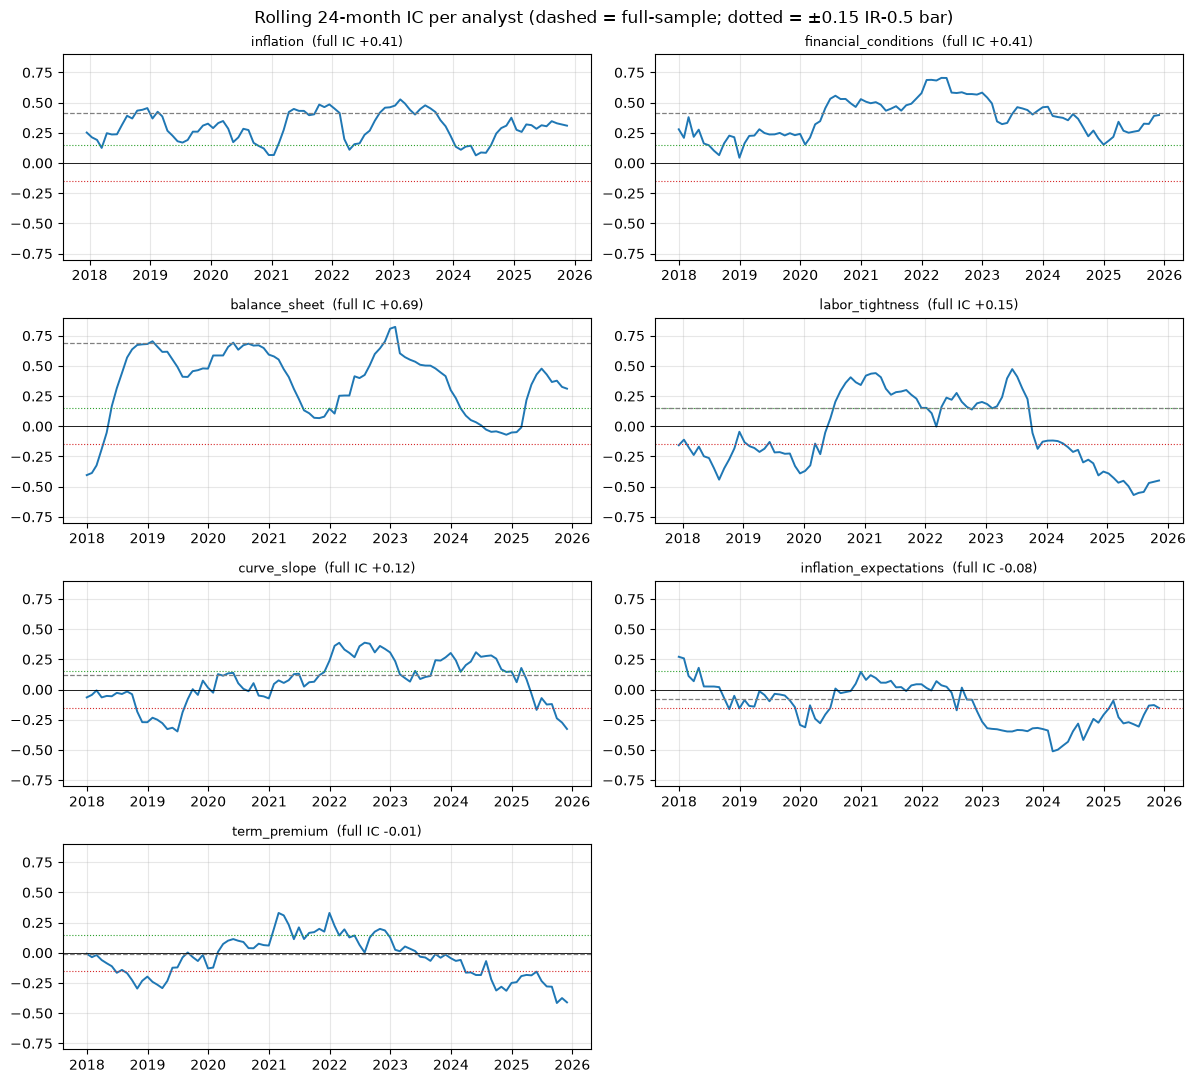

In [22]:
# §7.9 · Rolling 24-month IC per analyst.
from src.layered.evaluation.ic import ICEvaluator
from src.layered.evaluation.runs import load_run
def rolling_ic(signed, level, window=24, steps=1):
    ev = ICEvaluator(level, steps=steps); out = ev.outcome
    pair = pd.concat([signed.rename('s'), out.rename('o')], axis=1).dropna()
    v = [np.nan] * len(pair)
    for i in range(window - 1, len(pair)):
        w = pair.iloc[i - window + 1:i + 1]
        v[i] = w['s'].rank().corr(w['o'].rank())
    return pd.Series(v, index=pair.index)
fig, axes = plt.subplots(4, 2, figsize=(12, 11)); axes = axes.ravel()
for ax, d in zip(axes, DRIVERS):
    r = load_run(f'../reports/ab/{d}_on.jsonl')
    ric = rolling_ic(r.signed, r.level, 24)
    full = ICEvaluator(r.level).evaluate(r.signed).as_row()['ic']
    ax.plot(ric.index, ric.values, color='tab:blue', lw=1.4)
    ax.axhline(0, color='k', lw=.6)
    ax.axhline(0.15, color='tab:green', ls=':', lw=.8); ax.axhline(-0.15, color='tab:red', ls=':', lw=.8)
    ax.axhline(full, color='0.5', ls='--', lw=.9)
    ax.set_title(f'{d}  (full IC {full:+.2f})', fontsize=9); ax.set_ylim(-0.8, 0.9); ax.grid(alpha=.3)
for extra in axes[len(DRIVERS):]: extra.axis('off')
fig.suptitle('Rolling 24-month IC per analyst (dashed = full-sample; dotted = ±0.15 IR-0.5 bar)')
plt.tight_layout()

### 7.10 · Is the PM turning analyst views into good *trades*?

Two ways the PM could weight an analyst. **Left — by own-driver IC:** how faithfully it echoes the analyst's skill at its own driver (taking the panel at face value). **Right — by trade IC:** how well that analyst's view converts into a good trade. **The goal is the right panel.** Axes are standardized within pod, so identity (y=x) means the PM's weight tracks that axis. The PM is **welded to the left diagonal** — it faithfully echoes analyst confidence (corr ≈ 0.9–1.0) — and sits **off the right one** (weight is ~0/negatively related to trade value). A PM that reasons *for the trade* should live on the right diagonal; that migration is exactly what the relevance-prior arm targets (§7.11).

,"corr(weight, own_IC)","corr(weight, trade_IC)"
pod,,
curve,0.4,-0.8
duration,0.9,-0.1
front_end,1.0,-0.4
real,0.5,0.5


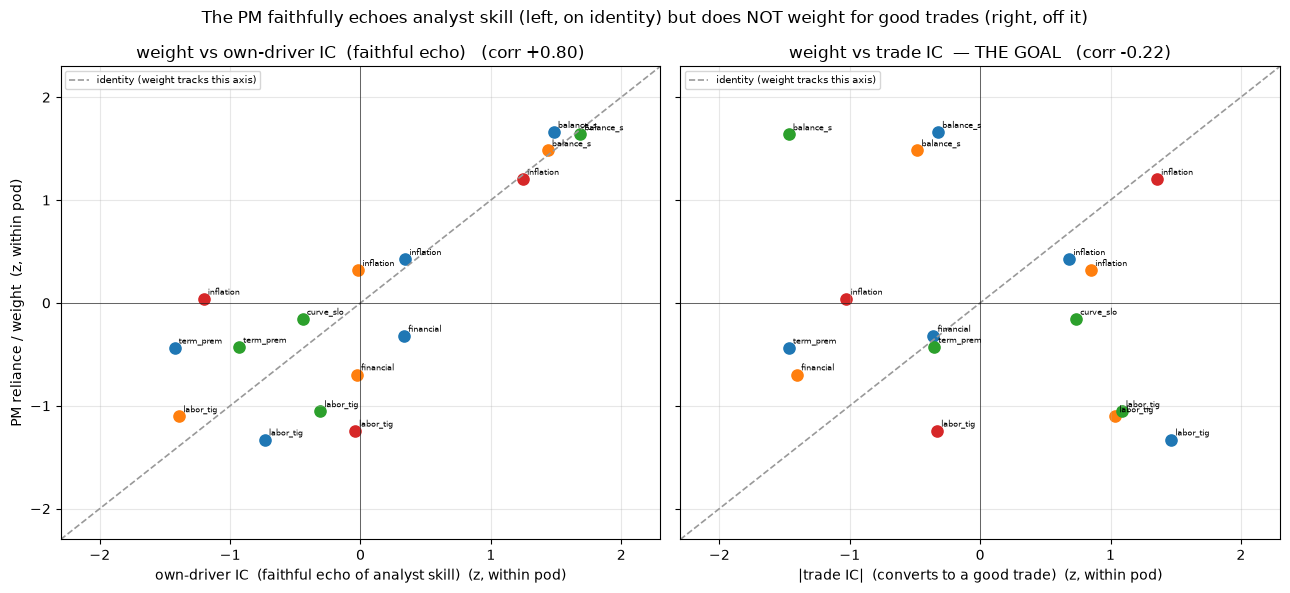

In [23]:
# §7.10 · PM weight vs own-driver IC (faithful echo) | vs |trade IC| (good trades = the goal).
from src.layered.evaluation.runs import load_run
from src.layered.evaluation.ic import ICEvaluator
DIRS = {'up': 1.0, 'down': -1.0, 'flat': 0.0}
macro2 = load_bundle(['DGS2', 'DGS10', 'T10YIE'])
def traded_outcome(pod):
    me = lambda s: macro2[s].dropna().resample('ME').last()
    y = {'duration': (me('DGS2') + me('DGS10')) / 2, 'front_end': me('DGS2'),
         'curve': me('DGS10') - me('DGS2'), 'real': me('T10YIE')}[pod]
    return y.shift(-1) - y
own_ic = {}
for d in DRIVERS:
    r = load_run(f'../reports/ab/{d}_on.jsonl'); own_ic[d] = ICEvaluator(r.level).evaluate(r.signed).as_row()['ic']
rows = []
for pod in PODS:
    p = build_pm(pod, None); pol = p.polarity; drv = list(p.listens_to); wt = {d: [] for d in drv}; recs = {}
    for line in open(f'../reports/pm/{pod}_mem_on.jsonl'):
        rr = json.loads(line)
        if rr.get('degraded'): continue
        dv = (rr.get('arbitrated') or {}).get('drivers') or {}; b = rr.get('board', {})
        for d in drv:
            if d in dv: wt[d].append(abs(dv[d]))
        recs[pd.Timestamp(rr['asof'])] = {d: DIRS.get(b.get(d, {}).get('direction', 'flat'), 0)
            * float(b.get(d, {}).get('conviction', 0)) * pol.get(d, 1.0) for d in drv}
    P = pd.DataFrame(recs).T.sort_index(); out = traded_outcome(pod).reindex(P.index)
    for d in drv:
        pair = pd.concat([P[d].rename('s'), out.rename('o')], axis=1).dropna()
        tic = pair['s'].rank().corr(pair['o'].rank()) if len(pair) > 5 else np.nan
        rows.append({'pod': pod, 'driver': d, 'weight': float(np.mean(wt[d])),
                     'own_ic': own_ic[d], 'trade_rel': abs(float(tic))})
rel = pd.DataFrame(rows)
def _z(s): return (s - s.mean()) / s.std(ddof=0) if s.std(ddof=0) > 0 else s * 0
for c in ['weight', 'own_ic', 'trade_rel']:
    rel[c + '_z'] = rel.groupby('pod')[c].transform(_z)
cmap = {'duration': 'tab:blue', 'front_end': 'tab:orange', 'curve': 'tab:green', 'real': 'tab:red'}
fig, ax = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
panels = [('own_ic_z', 'own-driver IC  (faithful echo of analyst skill)', 'weight vs own-driver IC  (faithful echo)'),
          ('trade_rel_z', '|trade IC|  (converts to a good trade)', 'weight vs trade IC  — THE GOAL')]
lim = [-2.3, 2.3]
for j, (xcol, xlabel, title) in enumerate(panels):
    ax[j].plot(lim, lim, ls='--', color='0.6', lw=1.2, label='identity (weight tracks this axis)')
    for _, r2 in rel.iterrows():
        ax[j].scatter(r2[xcol], r2['weight_z'], color=cmap[r2['pod']], s=65)
        ax[j].annotate(r2['driver'][:9], (r2[xcol], r2['weight_z']), fontsize=6, xytext=(3, 3), textcoords='offset points')
    c = rel[xcol].corr(rel['weight_z'])
    ax[j].set_xlim(lim); ax[j].set_ylim(lim); ax[j].axhline(0, color='k', lw=.4); ax[j].axvline(0, color='k', lw=.4)
    ax[j].set_xlabel(xlabel + '  (z, within pod)'); ax[j].grid(alpha=.3); ax[j].legend(fontsize=7, loc='upper left')
    ax[j].set_title(f'{title}   (corr {c:+.2f})')
ax[0].set_ylabel('PM reliance / weight  (z, within pod)')
fig.suptitle('The PM faithfully echoes analyst skill (left, on identity) but does NOT weight for good trades (right, off it)')
plt.tight_layout()
rel.groupby('pod').apply(lambda g: pd.Series({
    'corr(weight, own_IC)': round(g['weight'].rank().corr(g['own_ic'].rank()), 2),
    'corr(weight, trade_IC)': round(g['weight'].rank().corr(g['trade_rel'].rank()), 2)}))

## 8 · Verdict — fresh board

**The memory-on win did not replicate.** In §4 (July board) memory-on cleared mechanical at
t=+1.73. On the fresh board it beats mechanical on **0 of 3** pods that have a baseline
(duration +0.0055 < mech +0.0105; front_end −0.0010, with mem_off +0.019 and blind +0.027
both higher; real +0.0007 < mech +0.0129). No full-arbitration arm clears t=2. The earlier
result was board-specific noise — the one-board-fluke caveat was correct.

**Analyst layer (§7.1).** Three strong legs — balance_sheet, inflation, financial_conditions —
capture their feature-IC floor. Three legs leave measurable signal on the table: labor,
curve, and inflation_expectations (the last is *anti-signal* — it reasons backwards).
term_premium is a genuine limit: its feature floor is itself insignificant.

**Less structure beats more.** front_end *blind* (the PM sees a single report) is the only
t>2 in the whole matrix, and memory-off > memory-on. Scrambling which report belongs to
which driver leaves the duration trade 74.5% direction-unchanged (§7.3) — the arbitration
barely depends on correct attribution. (~17 P&L cells scored → treat the lone blind t=2.73
as *directional*, not decisive.)

**Read.** On a properly-controlled board the layered PM shows **no P&L edge over the
mechanical rule**. The tractable next target is the three under-extracting analyst legs —
the PM cannot arbitrate signal that isn't there. Full write-up: `docs/first-final-results.md`.